# Jayanagar AQI — Exploratory Data Analysis

**Station:** Jayanagar, Bangalore  
**Period:** Jan 2021 – Dec 2025  
**Granularity (raw):** Hourly → resampled to Daily  
**Target variable:** `AQI` (Daily Mean)

This notebook prepares and explores the dataset for four downstream models:
- ARIMA (univariate, statistical)
- SARIMA (seasonal, univariate)
- XGBoost (gradient-boosted trees with engineered features)
- LSTM (deep learning sequence model)

---

## 0. Environment Setup

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ─────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

# ── AQI category helper ─────────────────────────────────────────
AQI_BINS   = [0, 50, 100, 200, 300, 400, 500]
AQI_LABELS = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
AQI_COLORS = ['#00e400', '#92d050', '#ffff00', '#ff7e00', '#ff0000', '#7e0023']

def aqi_category(series):
    return pd.cut(series, bins=AQI_BINS, labels=AQI_LABELS)

print('Environment ready.')

Environment ready.


---
## 1. Load & Clean Raw Data

In [42]:
# ── 1.1  Load ──────────────────────────────────────────────────
raw = pd.read_csv('D:/AQI_Project/Data/cleaned/Jayanagar_AQI_data.csv', parse_dates=['Timestamp'])
raw = raw.set_index('Timestamp').sort_index()

# Drop the text label column (not useful for modelling)
raw = raw.drop(columns=['AQI_Category'], errors='ignore')

# Strip '_sub' suffix — these are pollutant sub-index values
raw.columns = [c.replace('_sub', '') for c in raw.columns]

print(f'Raw shape     : {raw.shape}')
print(f'Date range    : {raw.index.min()}  →  {raw.index.max()}')
print(f'Columns       : {raw.columns.tolist()}')
print(f'Frequency     : hourly')
raw.head()

Raw shape     : (40399, 8)
Date range    : 2021-01-01 05:00:00  →  2025-12-31 23:00:00
Columns       : ['PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'AQI']
Frequency     : hourly


,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI
Timestamp,,,,,,,,
2021-01-01 05:00:00,NaN,NaN,NaN,NaN,NaN,4.42,42.89,42.89
2021-01-01 06:00:00,NaN,NaN,NaN,NaN,NaN,4.55,42.80,42.80
2021-01-01 07:00:00,NaN,NaN,NaN,NaN,NaN,5.20,42.90,42.90
2021-01-01 08:00:00,NaN,NaN,NaN,NaN,NaN,5.84,43.03,43.03
2021-01-01 09:00:00,NaN,NaN,NaN,NaN,NaN,7.06,43.07,43.07


Hourly missing value summary:
      Missing Count  Missing %
PM25           2232       5.52
PM10           2048       5.07
NO2            1454       3.60
SO2            1302       3.22
NH3            1299       3.22
CO             1445       3.58
O3              878       2.17
AQI               0       0.00


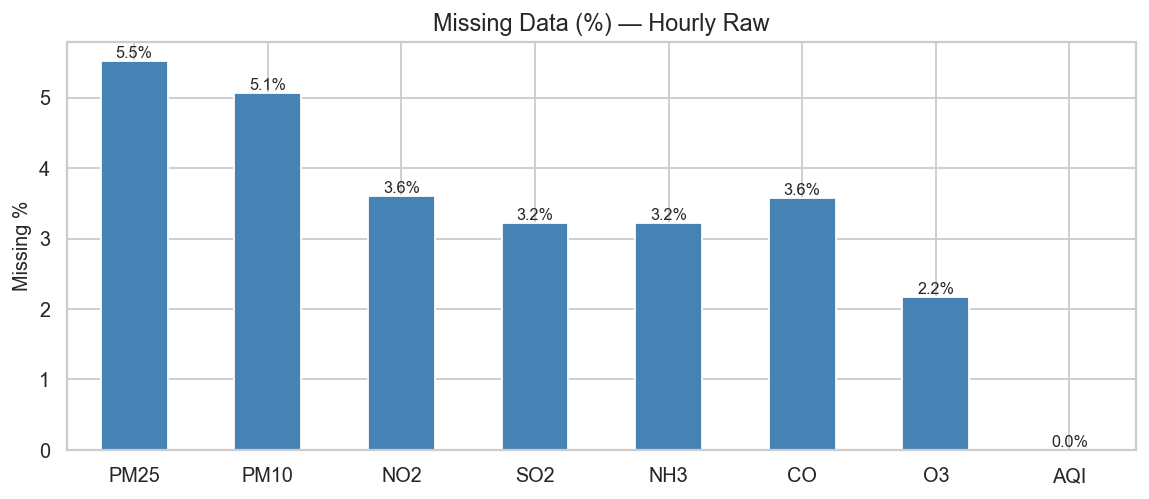

In [43]:
# ── 1.2  Missing values in raw hourly data ─────────────────────
null_pct = (raw.isnull().sum() / len(raw) * 100).round(2)
null_df  = pd.DataFrame({'Missing Count': raw.isnull().sum(),
                         'Missing %': null_pct})
print('Hourly missing value summary:')
print(null_df.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
null_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Missing Data (%) — Hourly Raw')
ax.set_ylabel('Missing %')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_01_missing_raw_Jayanagar.png', dpi=130)
plt.show()

In [44]:
# ── 1.3  Resample to daily mean ────────────────────────────────
# We aggregate first (mean), then interpolate the tiny residual NaNs
# so every model gets a complete, evenly-spaced daily series.

daily = raw.resample('D').mean()

# Linear interpolation for sparse missing days (max 1-4 days per column)
daily = daily.interpolate(method='linear', limit=4, limit_direction='both')

print(f'Daily shape   : {daily.shape}')
print(f'Remaining NaN : {daily.isnull().sum().sum()} (should be 0)')
print(f'Date range    : {daily.index.min().date()}  →  {daily.index.max().date()}')
daily.head()

Daily shape   : (1826, 8)
Remaining NaN : 63 (should be 0)
Date range    : 2021-01-01  →  2025-12-31


,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI
Timestamp,,,,,,,,
2021-01-01,118.841429,99.330000,31.394286,4.897143,3.588571,17.400000,43.502105,71.081579
2021-01-02,128.337500,103.167083,32.110833,5.295833,3.622917,20.220417,47.204783,128.337500
2021-01-03,94.291250,87.654348,32.397500,3.789167,3.625833,15.959583,34.831667,94.291250
2021-01-04,68.517917,66.222083,31.195833,3.963750,3.589167,21.344583,33.400000,69.166250
2021-01-05,62.749583,70.670417,33.487500,4.389167,3.727917,24.193333,34.567083,70.670417


In [45]:
# ── 1.4  Add derived columns for EDA ──────────────────────────
daily['AQI_Category'] = aqi_category(daily['AQI'])
daily['Year']         = daily.index.year
daily['Month']        = daily.index.month
daily['DayOfWeek']    = daily.index.dayofweek          # 0=Mon
daily['Season'] = daily['Month'].map({
    12:'Winter',  1:'Winter',  2:'Winter',
     3:'Summer',  4:'Summer',  5:'Summer',
     6:'Monsoon', 7:'Monsoon', 8:'Monsoon', 9:'Monsoon',
    10:'Post-Monsoon', 11:'Post-Monsoon'
})

print('Derived columns added:', ['AQI_Category','Year','Month','DayOfWeek','Season'])
daily.describe().round(2)

Derived columns added: ['AQI_Category', 'Year', 'Month', 'DayOfWeek', 'Season']


,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,Year,Month,DayOfWeek
count,1818.00,1818.00,1818.00,1818.00,1818.00,1818.00,1818.00,1819.00,1826.00,1826.00,1826.0
mean,57.01,66.37,21.27,9.95,1.88,23.73,26.27,70.94,2023.00,6.52,3.0
std,42.90,32.82,13.81,5.47,1.22,12.91,10.63,41.68,1.41,3.45,2.0
min,6.84,10.96,1.43,1.25,0.13,3.01,0.92,15.10,2021.00,1.00,0.0
25%,26.78,36.55,11.06,6.55,0.87,15.79,18.36,39.50,2022.00,4.00,1.0
50%,46.82,62.03,17.31,7.82,1.73,21.40,24.79,63.50,2023.00,7.00,3.0
75%,76.72,95.52,30.70,12.63,2.70,29.09,31.81,94.50,2024.00,10.00,5.0
max,485.86,174.96,127.86,36.71,14.90,123.82,104.58,485.86,2025.00,12.00,6.0


---
## 2. Descriptive Statistics

In [46]:
# ── 2.1  Pollutant distribution overview ───────────────────────
pollutants = ['PM25','PM10','NO2','SO2','NH3','CO','O3','AQI']

stats_df = daily[pollutants].agg(['mean','median','std','min','max',
                                   lambda x: x.quantile(0.25),
                                   lambda x: x.quantile(0.75)]).T
stats_df.columns = ['Mean','Median','Std','Min','Max','Q25','Q75']
print('Daily pollutant statistics:')
stats_df.round(2)

Daily pollutant statistics:


,Mean,Median,Std,Min,Max,Q25,Q75
PM25,57.01,46.82,42.90,6.84,485.86,26.78,76.72
PM10,66.37,62.03,32.82,10.96,174.96,36.55,95.52
NO2,21.27,17.31,13.81,1.43,127.86,11.06,30.70
SO2,9.95,7.82,5.47,1.25,36.71,6.55,12.63
NH3,1.88,1.73,1.22,0.13,14.90,0.87,2.70
CO,23.73,21.40,12.91,3.01,123.82,15.79,29.09
O3,26.27,24.79,10.63,0.92,104.58,18.36,31.81
AQI,70.94,63.50,41.68,15.10,485.86,39.50,94.50


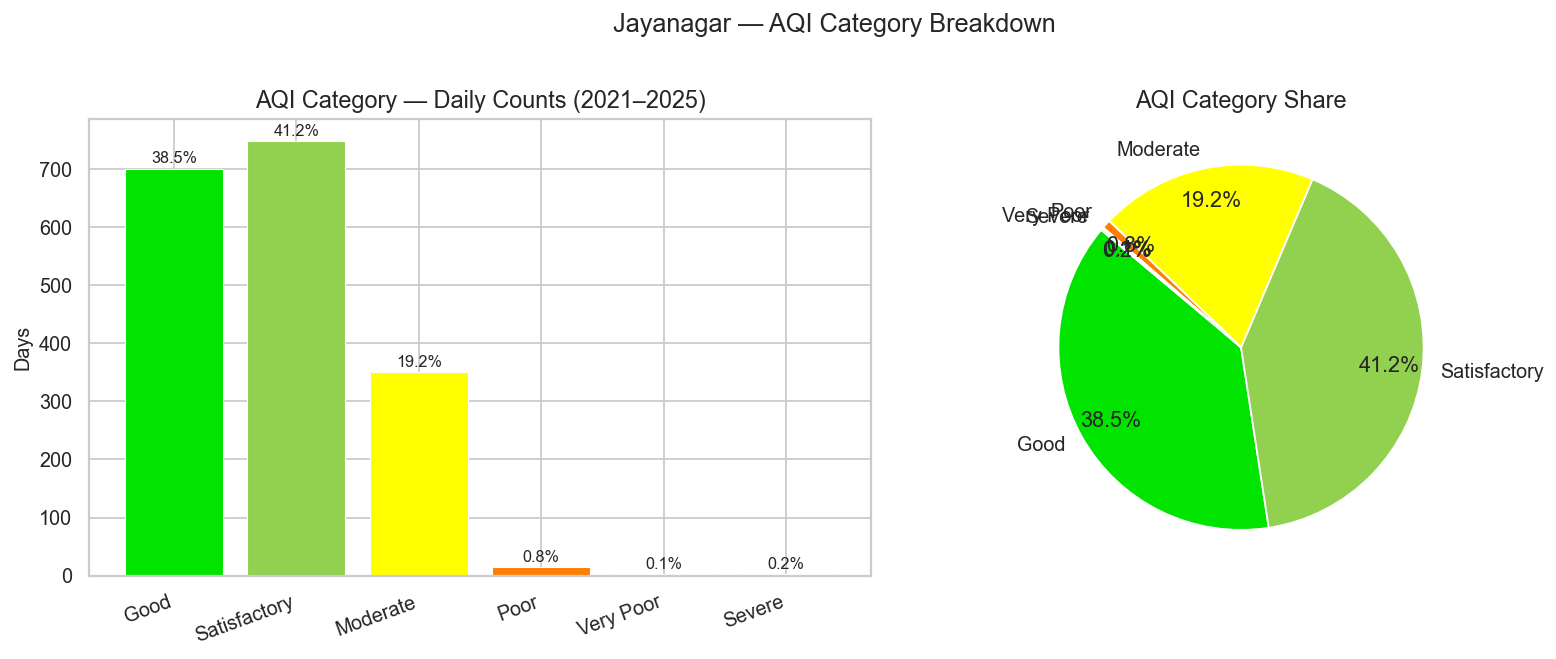


Note: Jayanagar spends ~0.1% of days in "Very Poor" and ~0.2% in "Severe" range.


In [47]:
# ── 2.2  AQI category distribution ────────────────────────────
cat_counts = daily['AQI_Category'].value_counts().reindex(AQI_LABELS)
cat_pct    = (cat_counts / cat_counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar
bars = axes[0].bar(cat_counts.index, cat_counts.values,
                   color=AQI_COLORS, edgecolor='white', linewidth=0.6)
axes[0].set_title('AQI Category — Daily Counts (2021–2025)')
axes[0].set_ylabel('Days')
axes[0].set_xticklabels(cat_counts.index, rotation=20, ha='right')
for bar, pct in zip(bars, cat_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 4, f'{pct}%',
                 ha='center', va='bottom', fontsize=9)

# Pie
axes[1].pie(cat_counts.values, labels=cat_counts.index,
            colors=AQI_COLORS, autopct='%1.1f%%',
            startangle=140, pctdistance=0.82)
axes[1].set_title('AQI Category Share')

plt.suptitle('Jayanagar — AQI Category Breakdown', fontsize=14, y=1.01)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_02_aqi_categories_Jayanagar.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nNote: Jayanagar spends ~0.1% of days in "Very Poor" and ~0.2% in "Severe" range.')

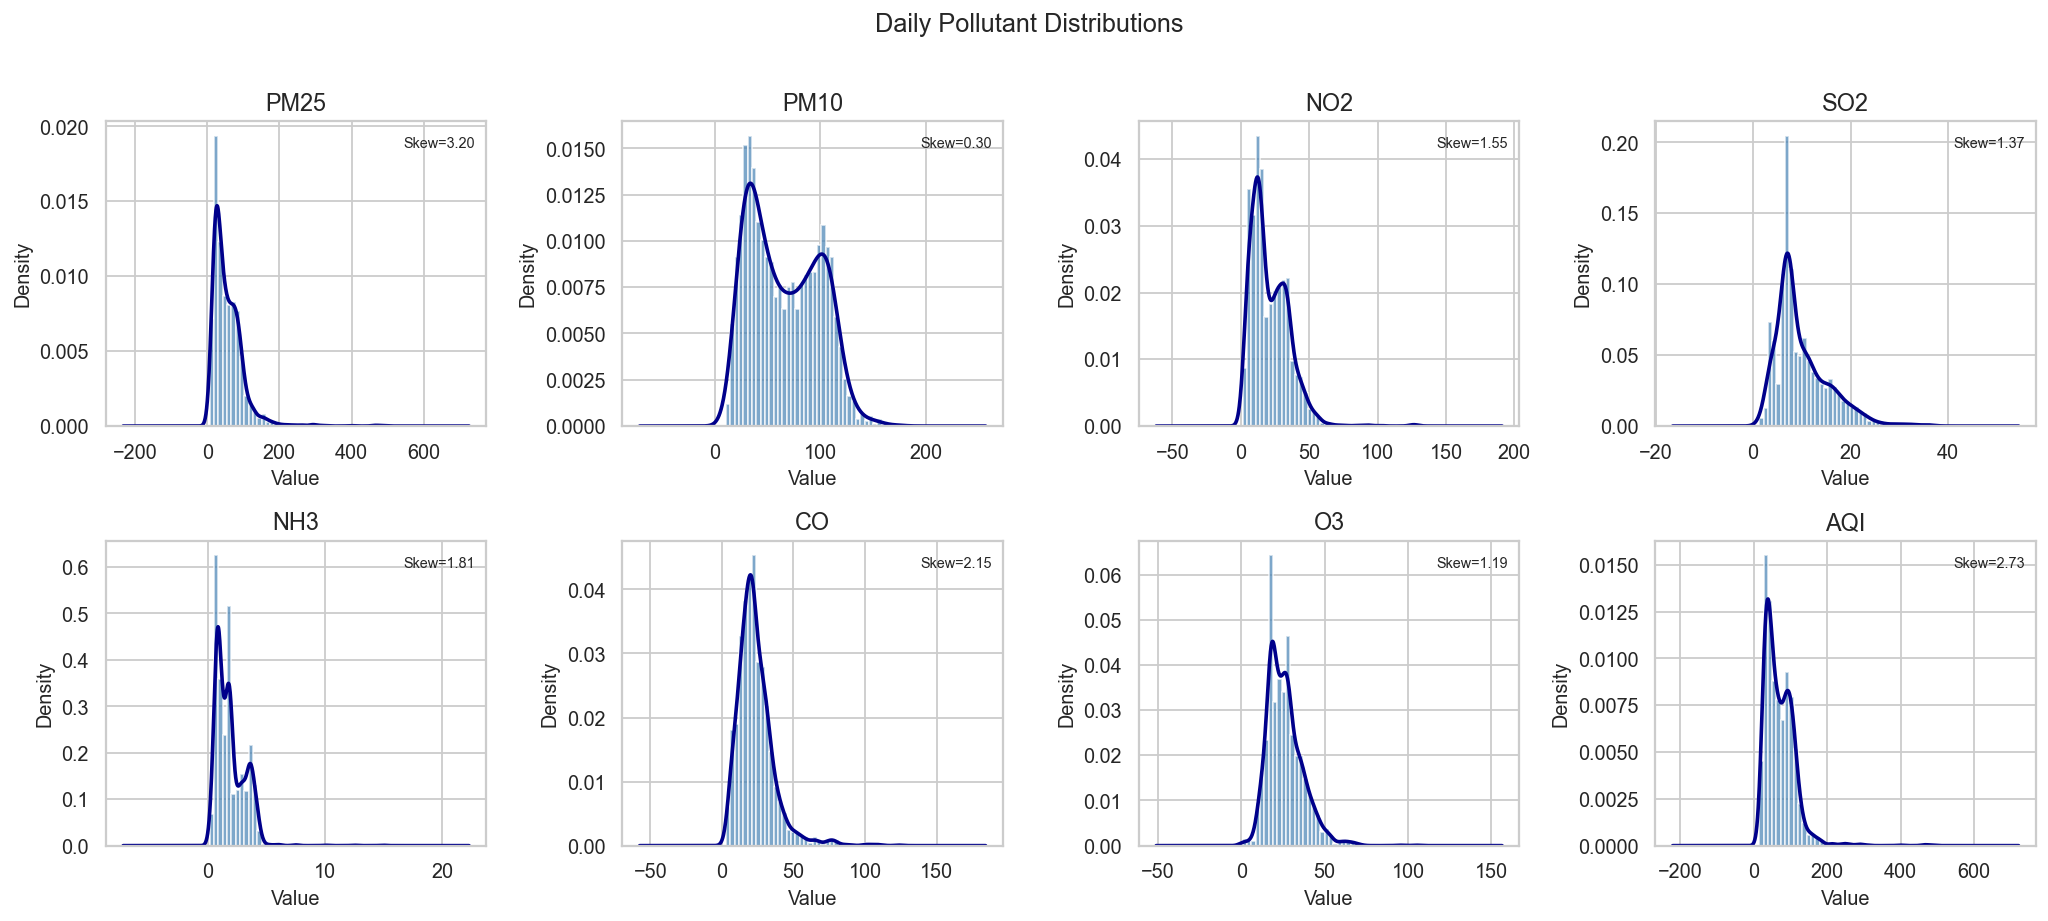

In [48]:
# ── 2.3  Pollutant distributions (histograms + KDE) ───────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(pollutants):
    data = daily[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white',
                 alpha=0.7, density=True)
    data.plot.kde(ax=axes[i], color='darkblue', linewidth=2)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    skew = data.skew()
    axes[i].text(0.97, 0.95, f'Skew={skew:.2f}',
                 transform=axes[i].transAxes, ha='right', va='top', fontsize=8)

plt.suptitle('Daily Pollutant Distributions', fontsize=14, y=1.01)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_03_distributions_Jayanagar.png', dpi=130, bbox_inches='tight')
plt.show()

In [49]:
# ── 2.4  Outlier detection via IQR ────────────────────────────
outlier_summary = {}
for col in pollutants:
    q1, q3 = daily[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((daily[col] < q1 - 1.5*iqr) | (daily[col] > q3 + 1.5*iqr)).sum()
    outlier_summary[col] = {'Q1': round(q1,2), 'Q3': round(q3,2),
                             'IQR': round(iqr,2), 'Outliers': n_outliers,
                             'Outlier%': round(n_outliers/len(daily)*100, 2)}

print('IQR-based outlier detection:')
pd.DataFrame(outlier_summary).T

IQR-based outlier detection:


,Q1,Q3,IQR,Outliers,Outlier%
PM25,26.78,76.72,49.94,52.0,2.85
PM10,36.55,95.52,58.97,0.0,0.00
NO2,11.06,30.70,19.64,14.0,0.77
SO2,6.55,12.63,6.08,69.0,3.78
NH3,0.87,2.70,1.84,8.0,0.44
CO,15.79,29.09,13.30,72.0,3.94
O3,18.36,31.81,13.45,40.0,2.19
AQI,39.50,94.50,55.00,27.0,1.48


---
## 3. Time-Series Visualisation

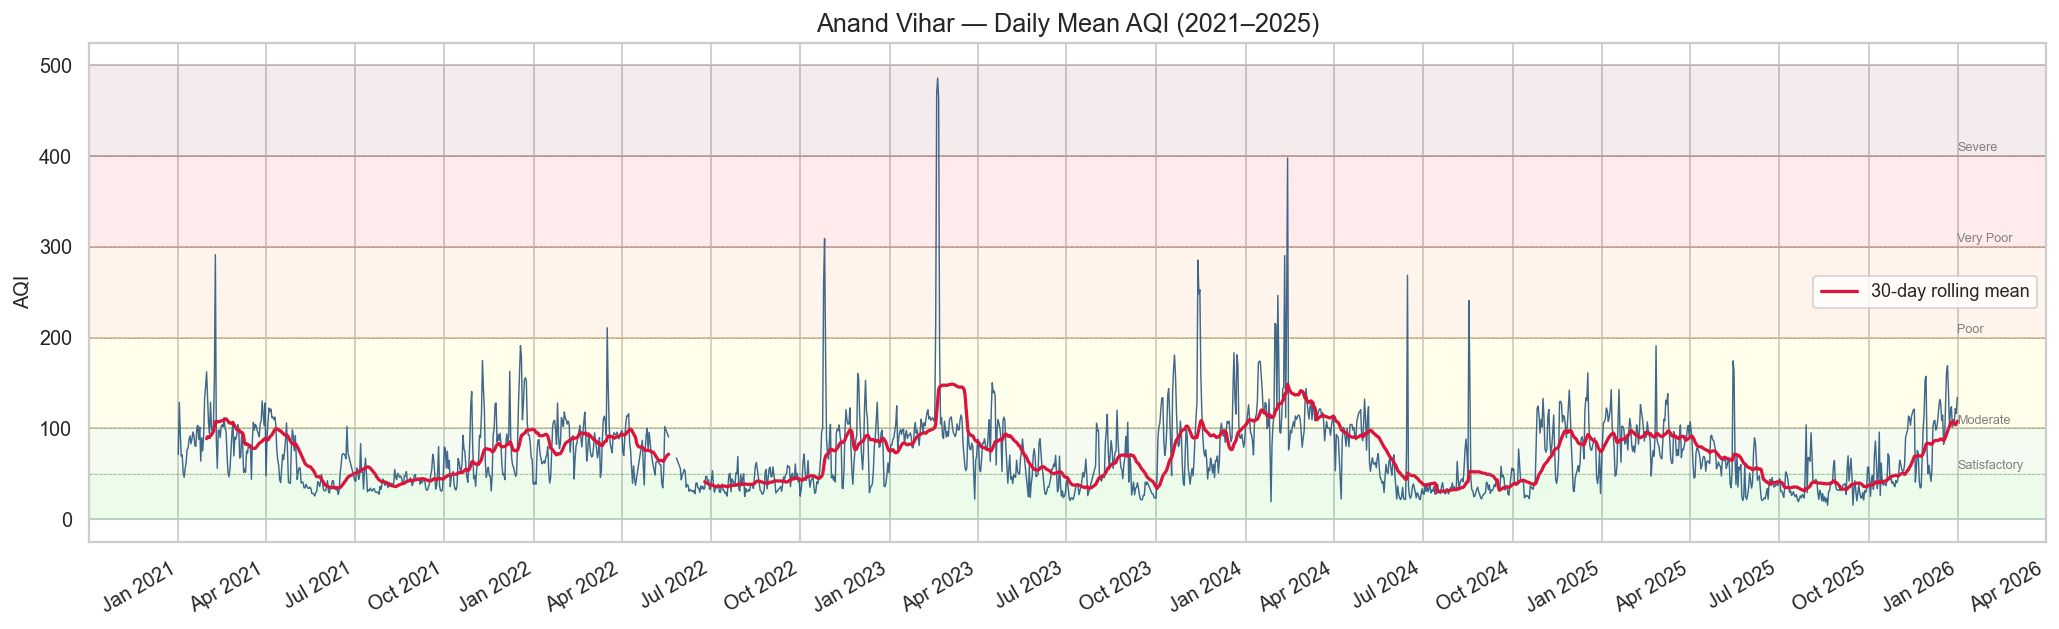

In [50]:
# ── 3.1  Full AQI time-series with category bands ──────────────
fig, ax = plt.subplots(figsize=(16, 5))

band_limits = list(zip(AQI_BINS[:-1], AQI_BINS[1:], AQI_COLORS, AQI_LABELS))
for lo, hi, color, label in band_limits:
    ax.axhspan(lo, hi, alpha=0.08, color=color)

ax.plot(daily.index, daily['AQI'], color='#1f4e79', linewidth=0.8, alpha=0.85)

# 30-day rolling mean
ax.plot(daily.index, daily['AQI'].rolling(30).mean(),
        color='crimson', linewidth=1.8, label='30-day rolling mean')

# Category threshold lines
for thresh, lbl in zip(AQI_BINS[1:-1], AQI_LABELS[1:]):
    ax.axhline(thresh, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.text(daily.index[-1], thresh+2, lbl, fontsize=7, color='grey', va='bottom')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')
ax.set_ylabel('AQI')
ax.set_title('Anand Vihar — Daily Mean AQI (2021–2025)', fontsize=14)
ax.legend()
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_04_aqi_full_series_Jayanagar.png', dpi=130)
plt.show()

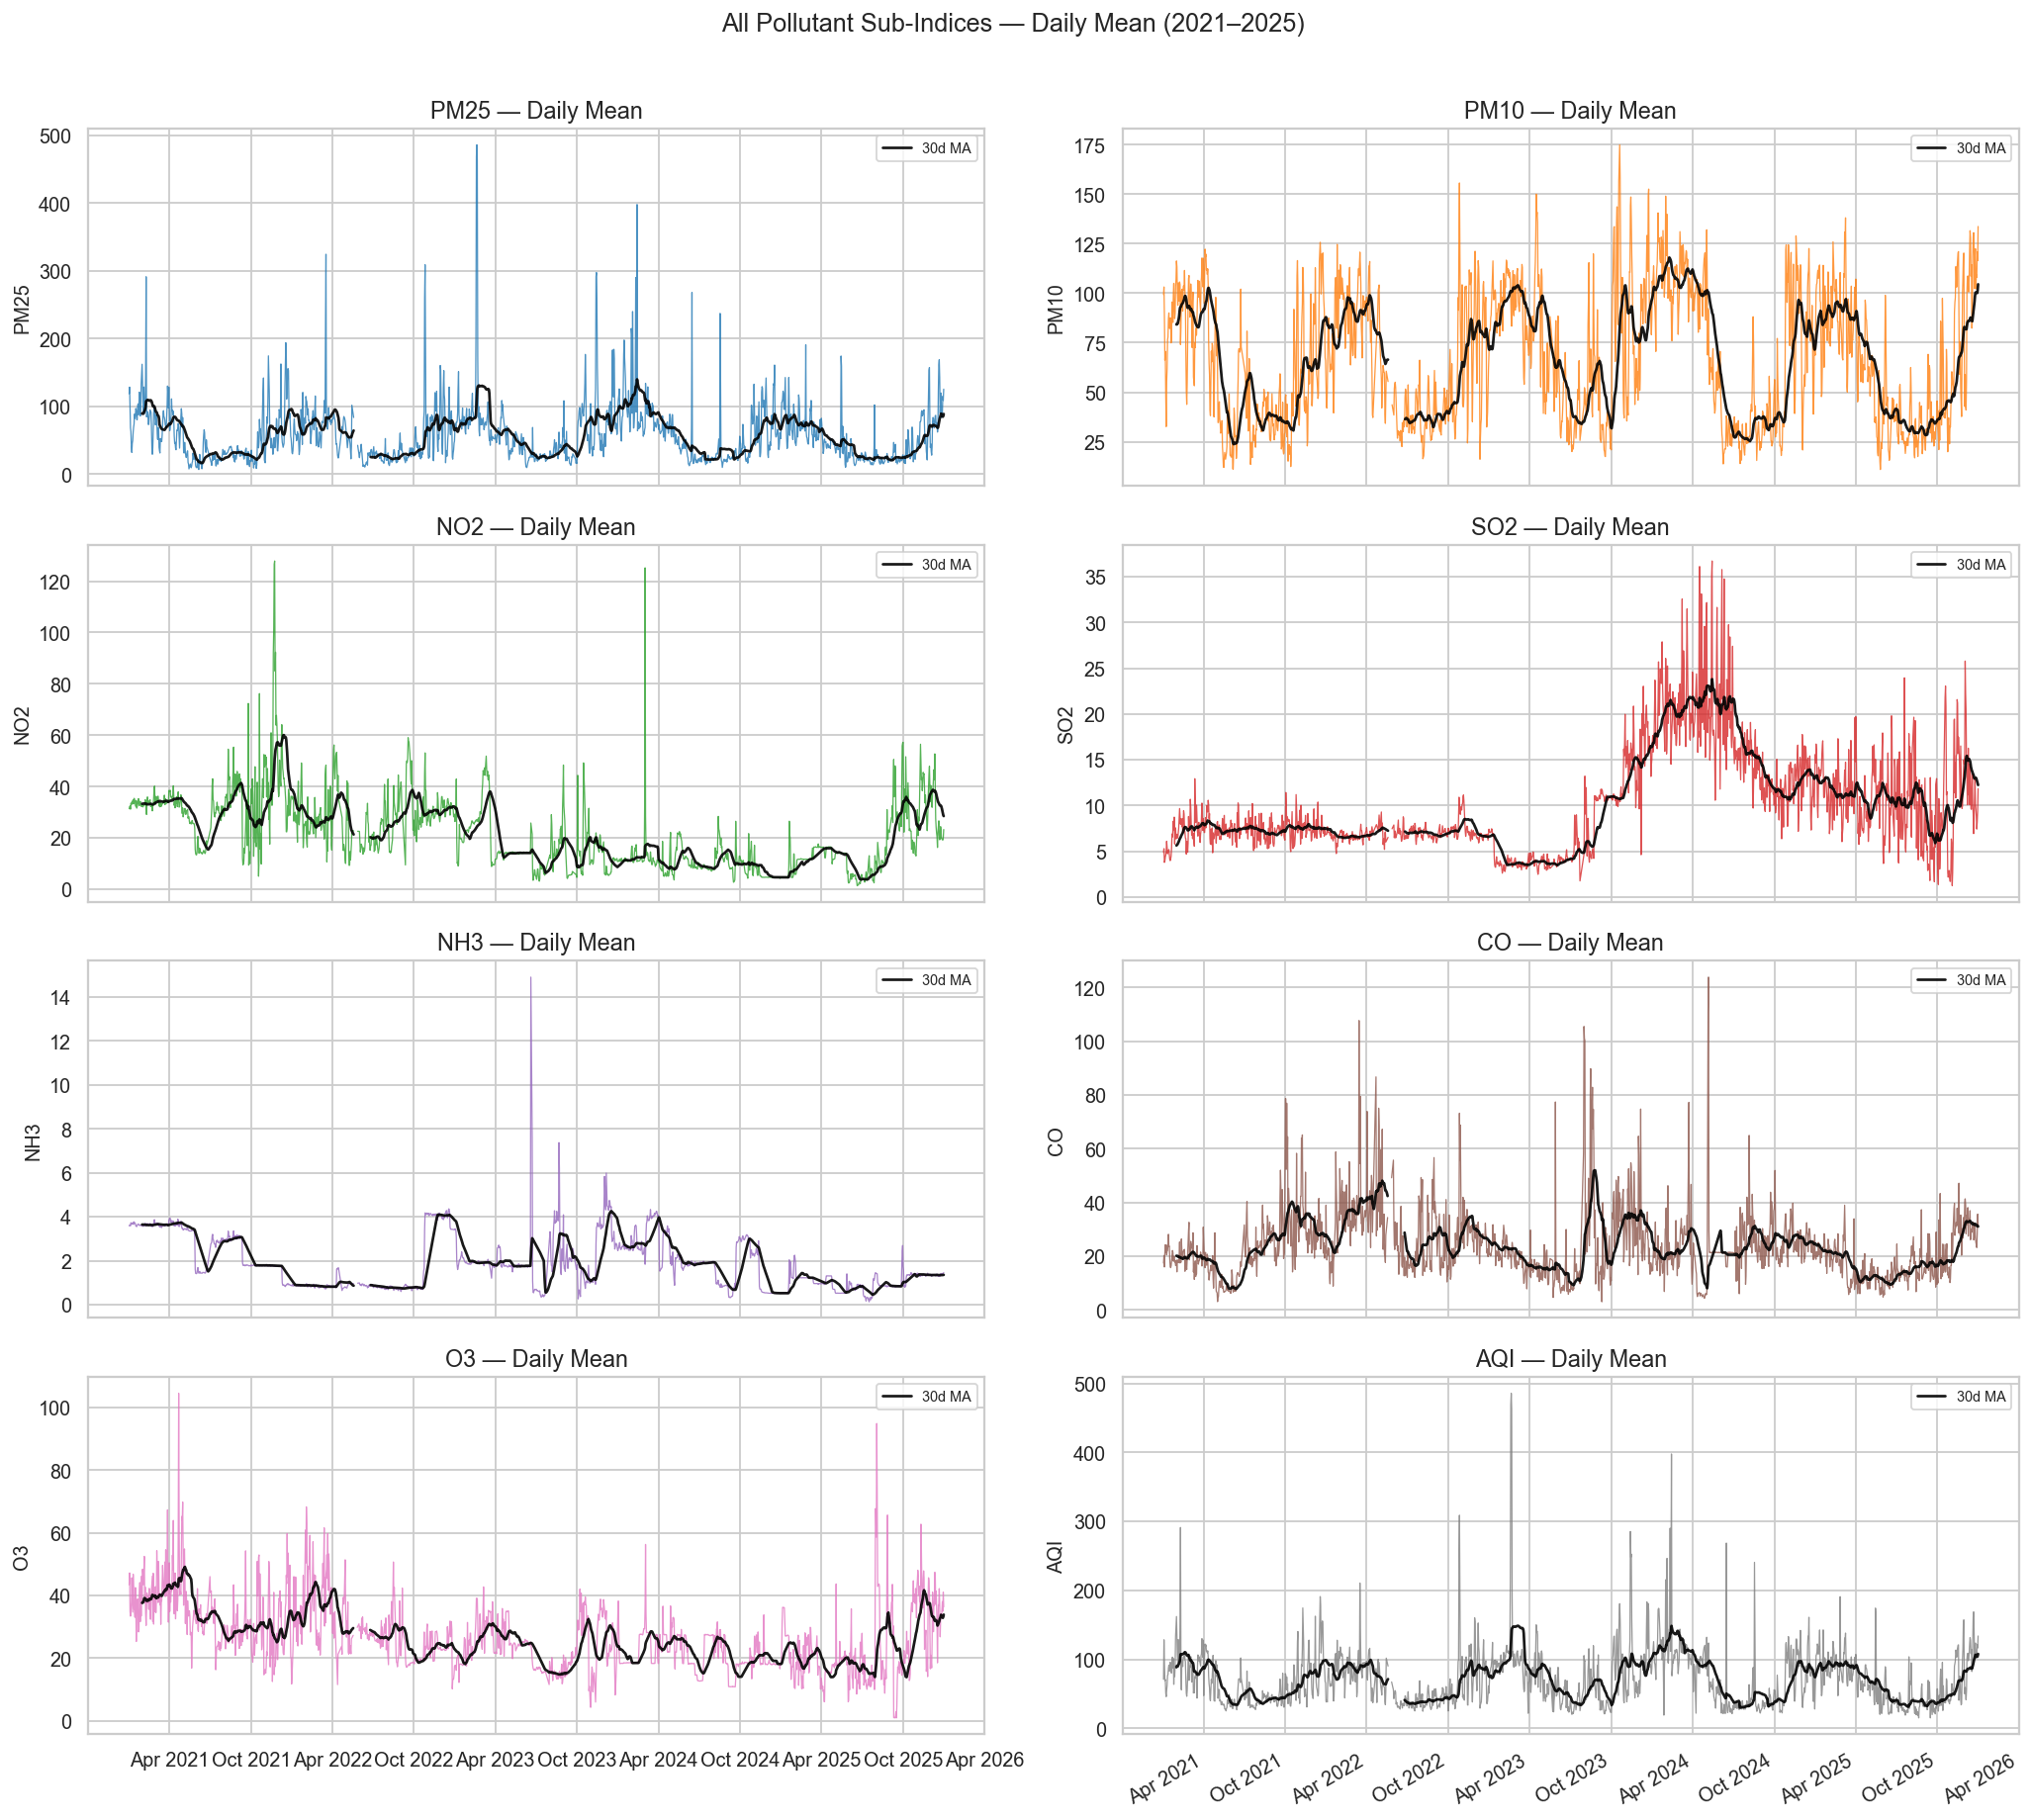

In [51]:
# ── 3.2  All pollutants over time ─────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()
colors = plt.cm.tab10.colors

for i, col in enumerate(pollutants):
    axes[i].plot(daily.index, daily[col], color=colors[i], linewidth=0.7, alpha=0.8)
    axes[i].plot(daily.index, daily[col].rolling(30).mean(),
                 color='black', linewidth=1.5, alpha=0.9, label='30d MA')
    axes[i].set_ylabel(col)
    axes[i].set_title(f'{col} — Daily Mean')
    axes[i].legend(fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')
plt.suptitle('All Pollutant Sub-Indices — Daily Mean (2021–2025)', fontsize=14, y=1.01)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_05_all_pollutants_Jayanagar.png', dpi=130, bbox_inches='tight')
plt.show()

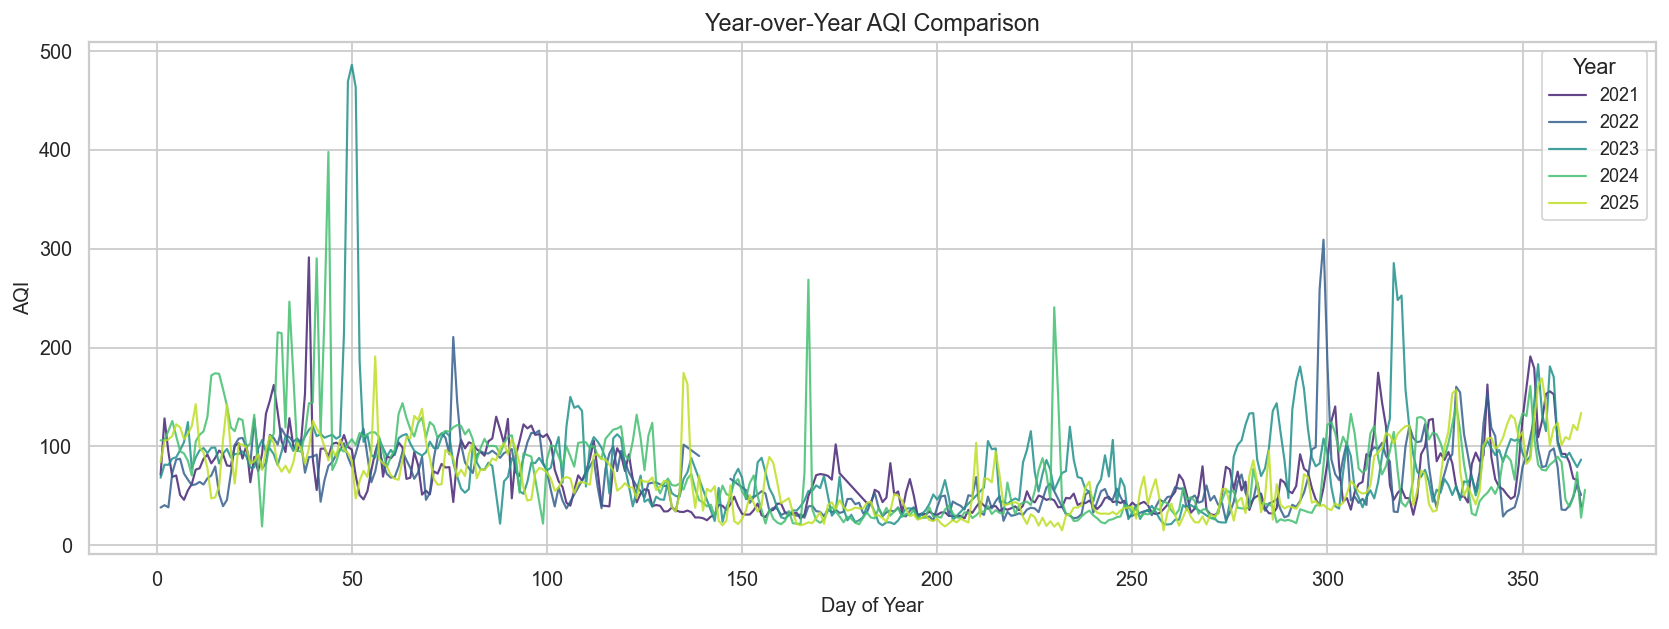

In [52]:
# ── 3.3  Year-over-year AQI overlay ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
year_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 5))

for year, color in zip(range(2021, 2026), year_colors):
    yr_data = daily[daily.index.year == year]['AQI']
    ax.plot(yr_data.index.dayofyear, yr_data.values,
            color=color, linewidth=1.2, alpha=0.85, label=str(year))

ax.set_xlabel('Day of Year')
ax.set_ylabel('AQI')
ax.set_title('Year-over-Year AQI Comparison')
ax.legend(title='Year')
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_06_yoy_aqi_Jayanagar.png', dpi=130)
plt.show()

---
## 4. Seasonality & Calendar Patterns

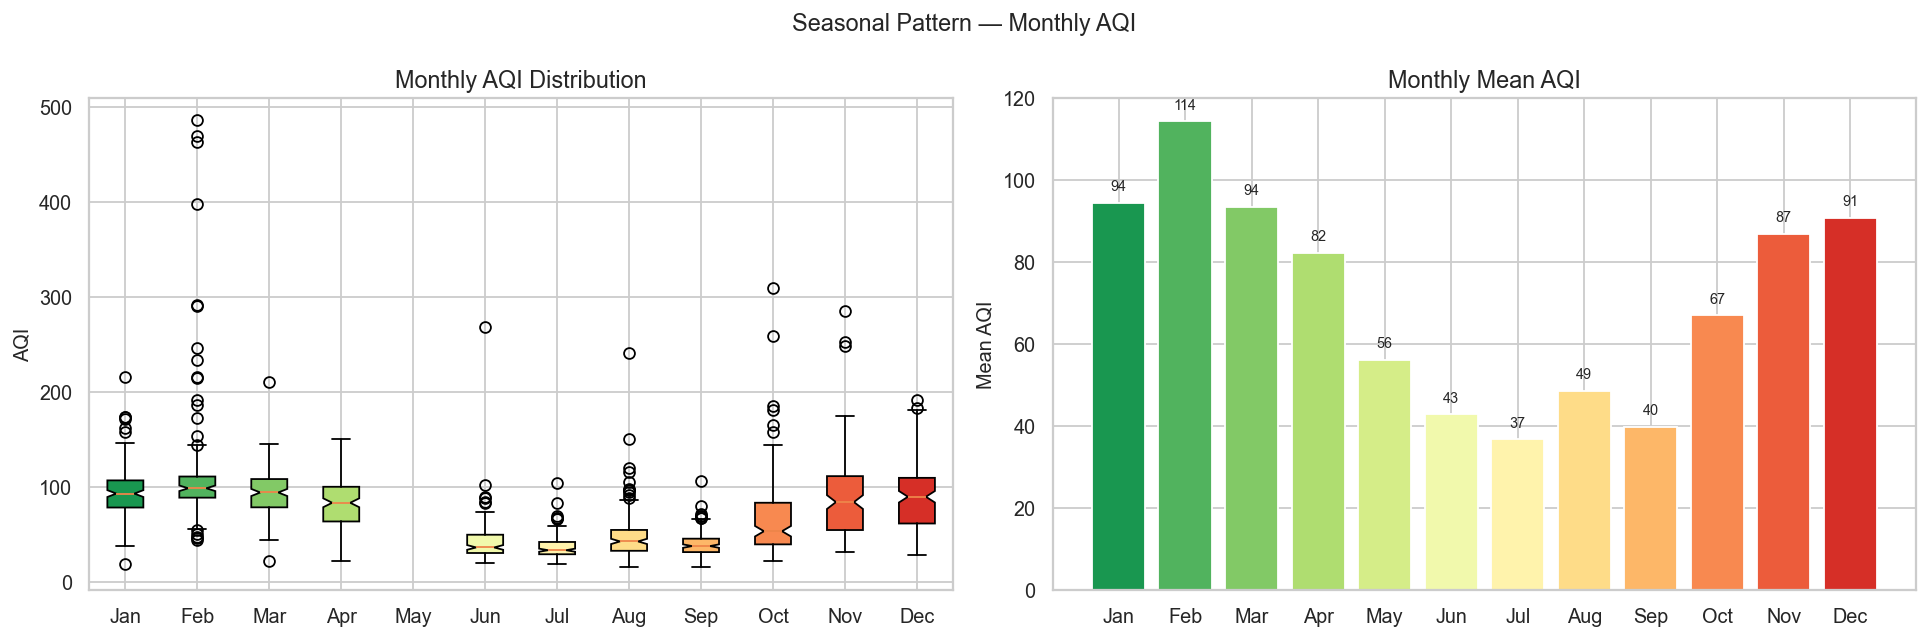


Key insight: AQI peaks in dry/winter months (traffic congestion + dust),
and dips in Jul–Sep (monsoon washout).


In [53]:
# ── 4.1  Monthly AQI boxplots ─────────────────────────────────
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
monthly_data = [daily[daily['Month'] == m]['AQI'].values for m in range(1, 13)]
bp = axes[0].boxplot(monthly_data, patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 12))):
    patch.set_facecolor(color)
axes[0].set_xticklabels(month_names)
axes[0].set_ylabel('AQI')
axes[0].set_title('Monthly AQI Distribution')

# Mean line
monthly_mean = daily.groupby('Month')['AQI'].mean()
axes[1].bar(month_names, monthly_mean.values,
            color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 12)),
            edgecolor='white')
axes[1].set_ylabel('Mean AQI')
axes[1].set_title('Monthly Mean AQI')
for i, v in enumerate(monthly_mean.values):
    axes[1].text(i, v+3, f'{v:.0f}', ha='center', fontsize=8)

plt.suptitle('Seasonal Pattern — Monthly AQI', fontsize=13)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_07_monthly_aqi_Jayanagar.png', dpi=130)
plt.show()

print('\nKey insight: AQI peaks in dry/winter months (traffic congestion + dust),')
print('and dips in Jul–Sep (monsoon washout).')

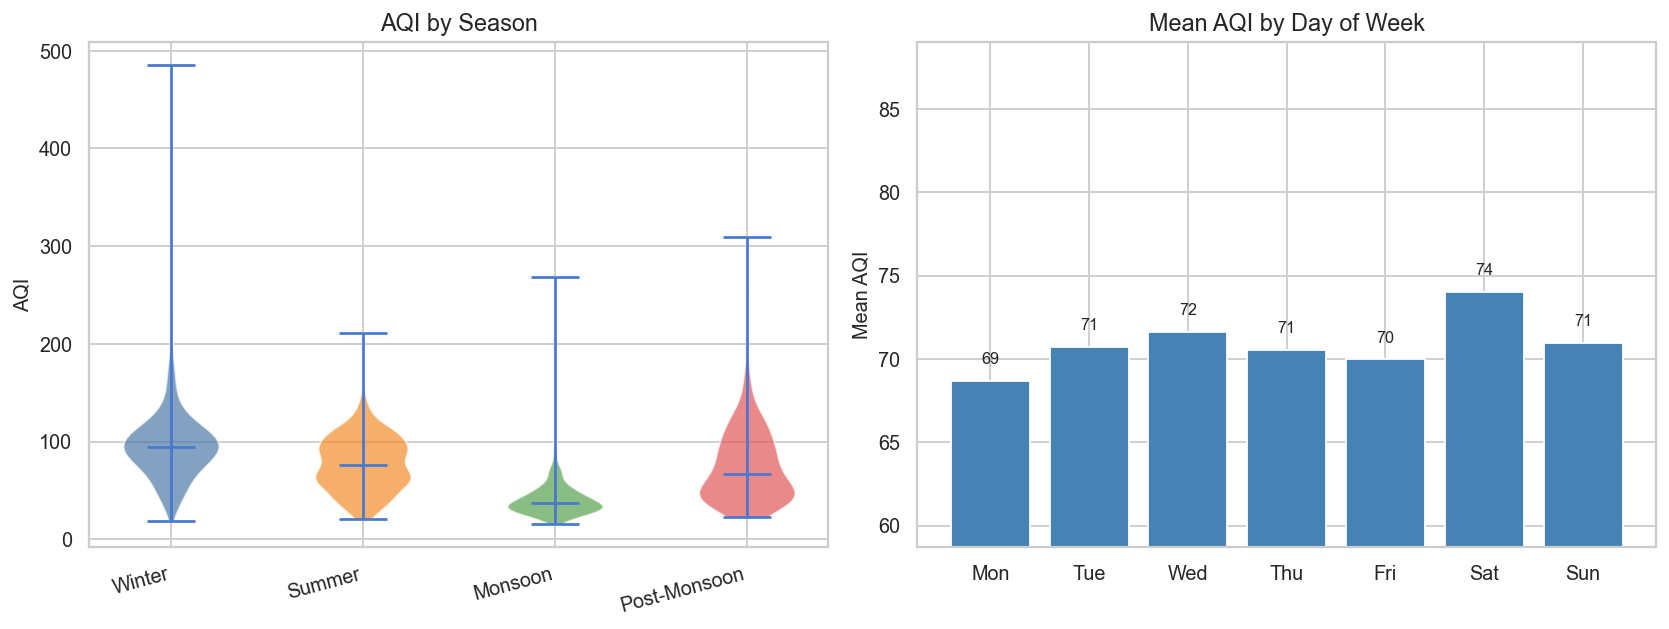


Day-of-week effect: minimal -- AQI is dominated by meteorology, not traffic alone.


In [54]:
# -- 4.2  Season and Day-of-Week effects ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Season violin -- uses Indian meteorological seasons
# (matching the Season column defined in the data-prep cell)
season_order   = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
season_palette = {
    'Winter':       '#4e79a7',
    'Summer':       '#f28e2b',
    'Monsoon':      '#59a14f',
    'Post-Monsoon': '#e15759',
}

# Guard against seasons with no data (avoids np.min() crash on empty arrays)
season_data_all = [daily[daily['Season'] == s]['AQI'].dropna().values for s in season_order]
valid_seasons   = [(s, d) for s, d in zip(season_order, season_data_all) if len(d) > 0]

if valid_seasons:
    valid_season_names = [s for s, _ in valid_seasons]
    valid_season_data  = [d for _, d in valid_seasons]
    vp = axes[0].violinplot(valid_season_data, showmedians=True)
    for body, s in zip(vp['bodies'], valid_season_names):
        body.set_facecolor(season_palette[s])
        body.set_alpha(0.7)
    axes[0].set_xticks(range(1, len(valid_season_names) + 1))
    axes[0].set_xticklabels(valid_season_names, rotation=15, ha='right')
else:
    axes[0].text(0.5, 0.5, 'No season data', ha='center', va='center',
                 transform=axes[0].transAxes)
axes[0].set_ylabel('AQI')
axes[0].set_title('AQI by Season')

# Day-of-week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_mean  = daily.groupby('DayOfWeek')['AQI'].mean()
axes[1].bar(day_names, dow_mean.values, color='steelblue', edgecolor='white')
axes[1].set_ylabel('Mean AQI')
axes[1].set_title('Mean AQI by Day of Week')
axes[1].set_ylim(dow_mean.min() - 10, dow_mean.max() + 15)
for i, v in enumerate(dow_mean.values):
    axes[1].text(i, v + 1, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_08_season_dow_jayanagar.png', dpi=130)
plt.show()

print('\nDay-of-week effect: minimal -- AQI is dominated by meteorology, not traffic alone.')


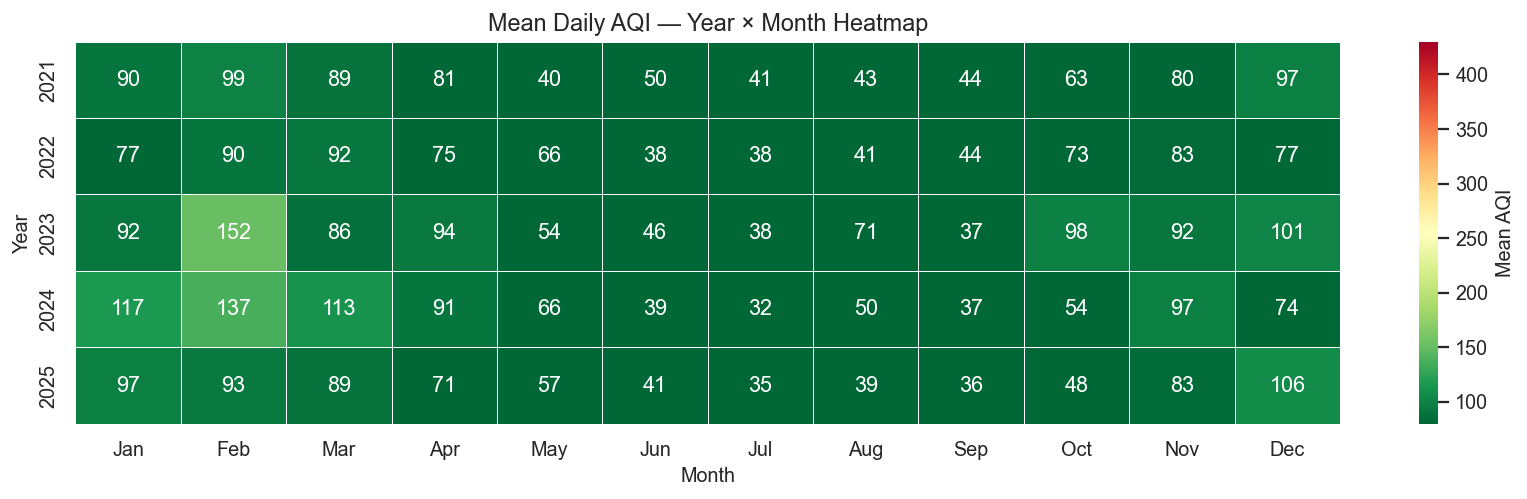

In [55]:
# ── 4.3  Heatmap: year × month ─────────────────────────────────
pivot = daily.pivot_table(values='AQI', index='Year', columns='Month', aggfunc='mean')
pivot.columns = month_names

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=80, vmax=430,
            cbar_kws={'label': 'Mean AQI'})
ax.set_title('Mean Daily AQI — Year × Month Heatmap', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_09_heatmap_year_month_Jayanagar.png', dpi=130)
plt.show()

---
## 5. Correlation & Multivariate Analysis

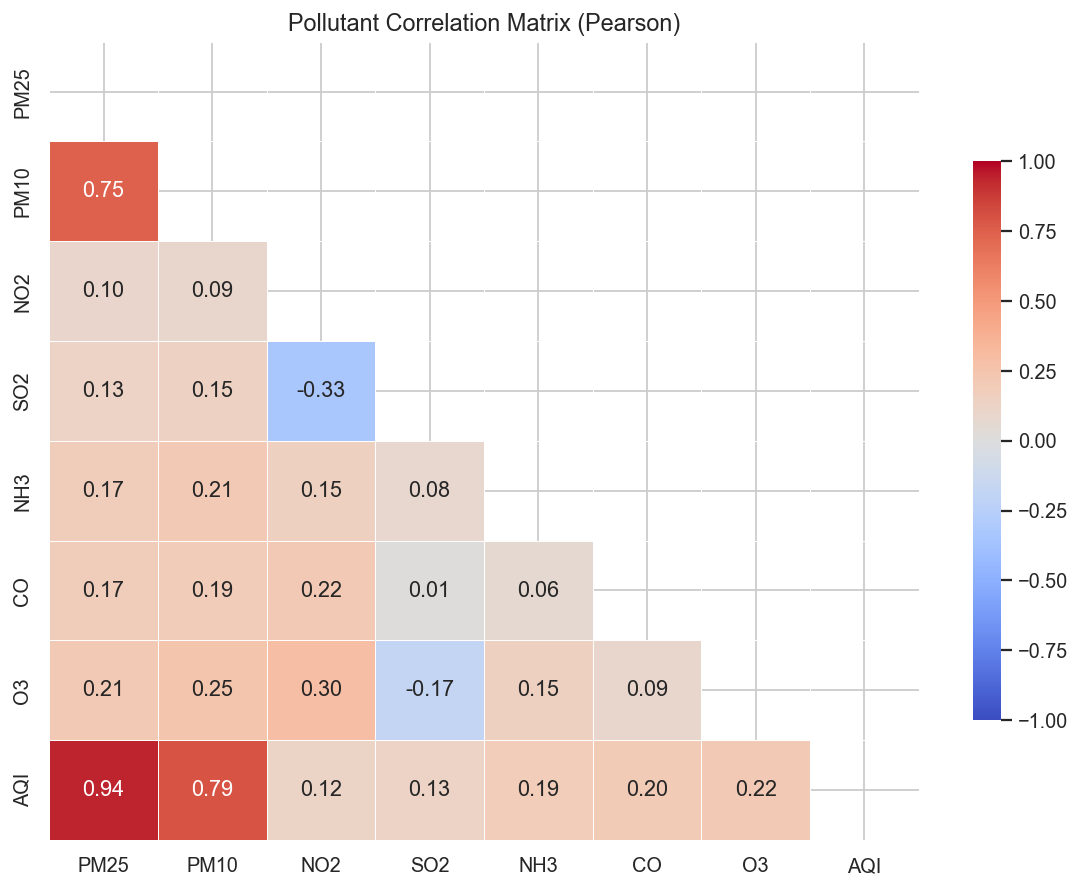


Correlations with AQI:
PM25    0.945
PM10    0.792
O3      0.218
CO      0.200
NH3     0.187
SO2     0.130
NO2     0.120


In [56]:
# ── 5.1  Pearson correlation heatmap ──────────────────────────
corr = daily[pollutants].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Pollutant Correlation Matrix (Pearson)', fontsize=13)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_10_correlation_Jayanagar.png', dpi=130)
plt.show()

print('\nCorrelations with AQI:')
print(corr['AQI'].drop('AQI').sort_values(ascending=False).round(3).to_string())

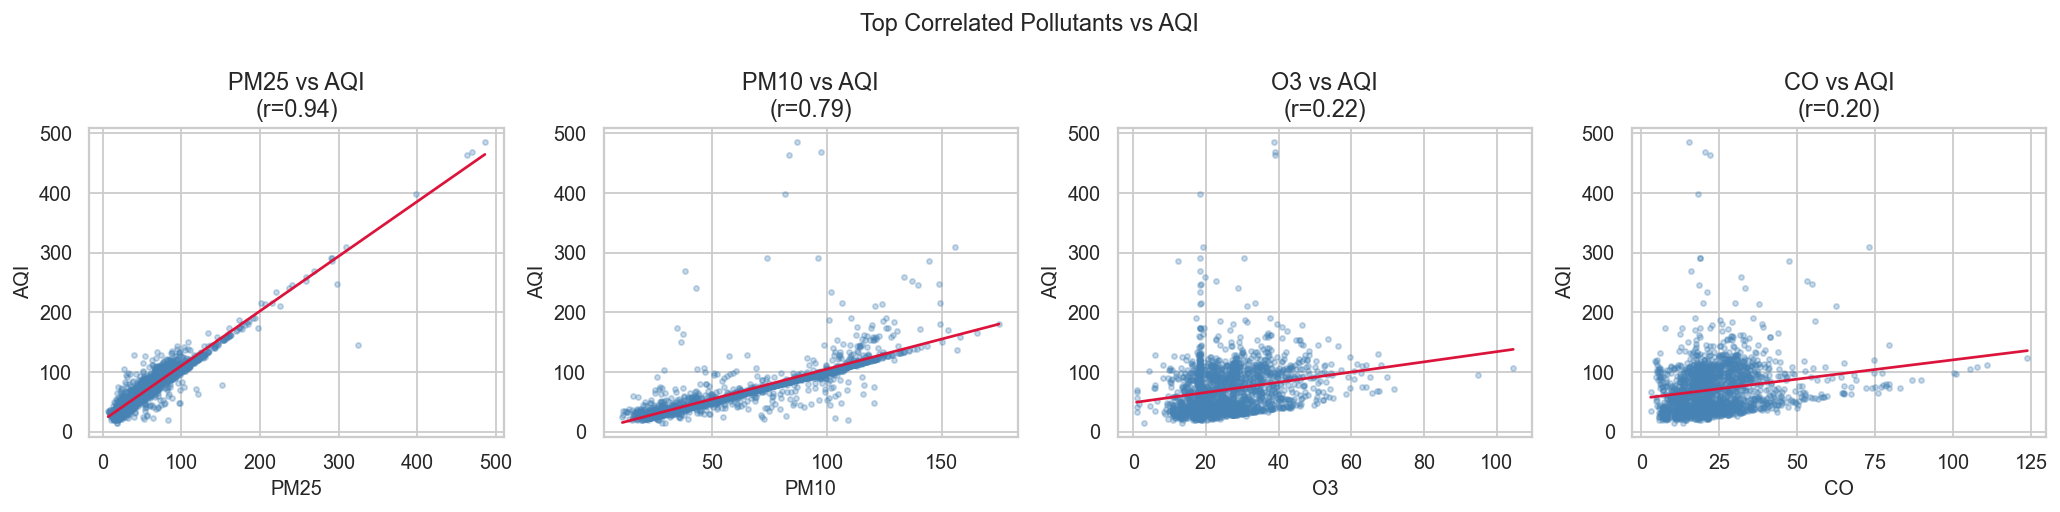

In [57]:
# ── 5.2  Scatter plots: top correlated pollutants vs AQI ──────
top_pollutants = corr['AQI'].drop('AQI').abs().sort_values(ascending=False).index[:4].tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, pol in zip(axes, top_pollutants):
    ax.scatter(daily[pol], daily['AQI'], alpha=0.3, s=8, color='steelblue')
    # regression line
    m, b, r, p, _ = stats.linregress(daily[pol].dropna(),
                                      daily.loc[daily[pol].notna(), 'AQI'])
    x = np.linspace(daily[pol].min(), daily[pol].max(), 100)
    ax.plot(x, m*x + b, color='crimson', linewidth=1.5)
    ax.set_xlabel(pol)
    ax.set_ylabel('AQI')
    ax.set_title(f'{pol} vs AQI\n(r={r:.2f})')

plt.suptitle('Top Correlated Pollutants vs AQI', fontsize=13)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_11_scatter_aqi_Jayanagar.png', dpi=130)
plt.show()

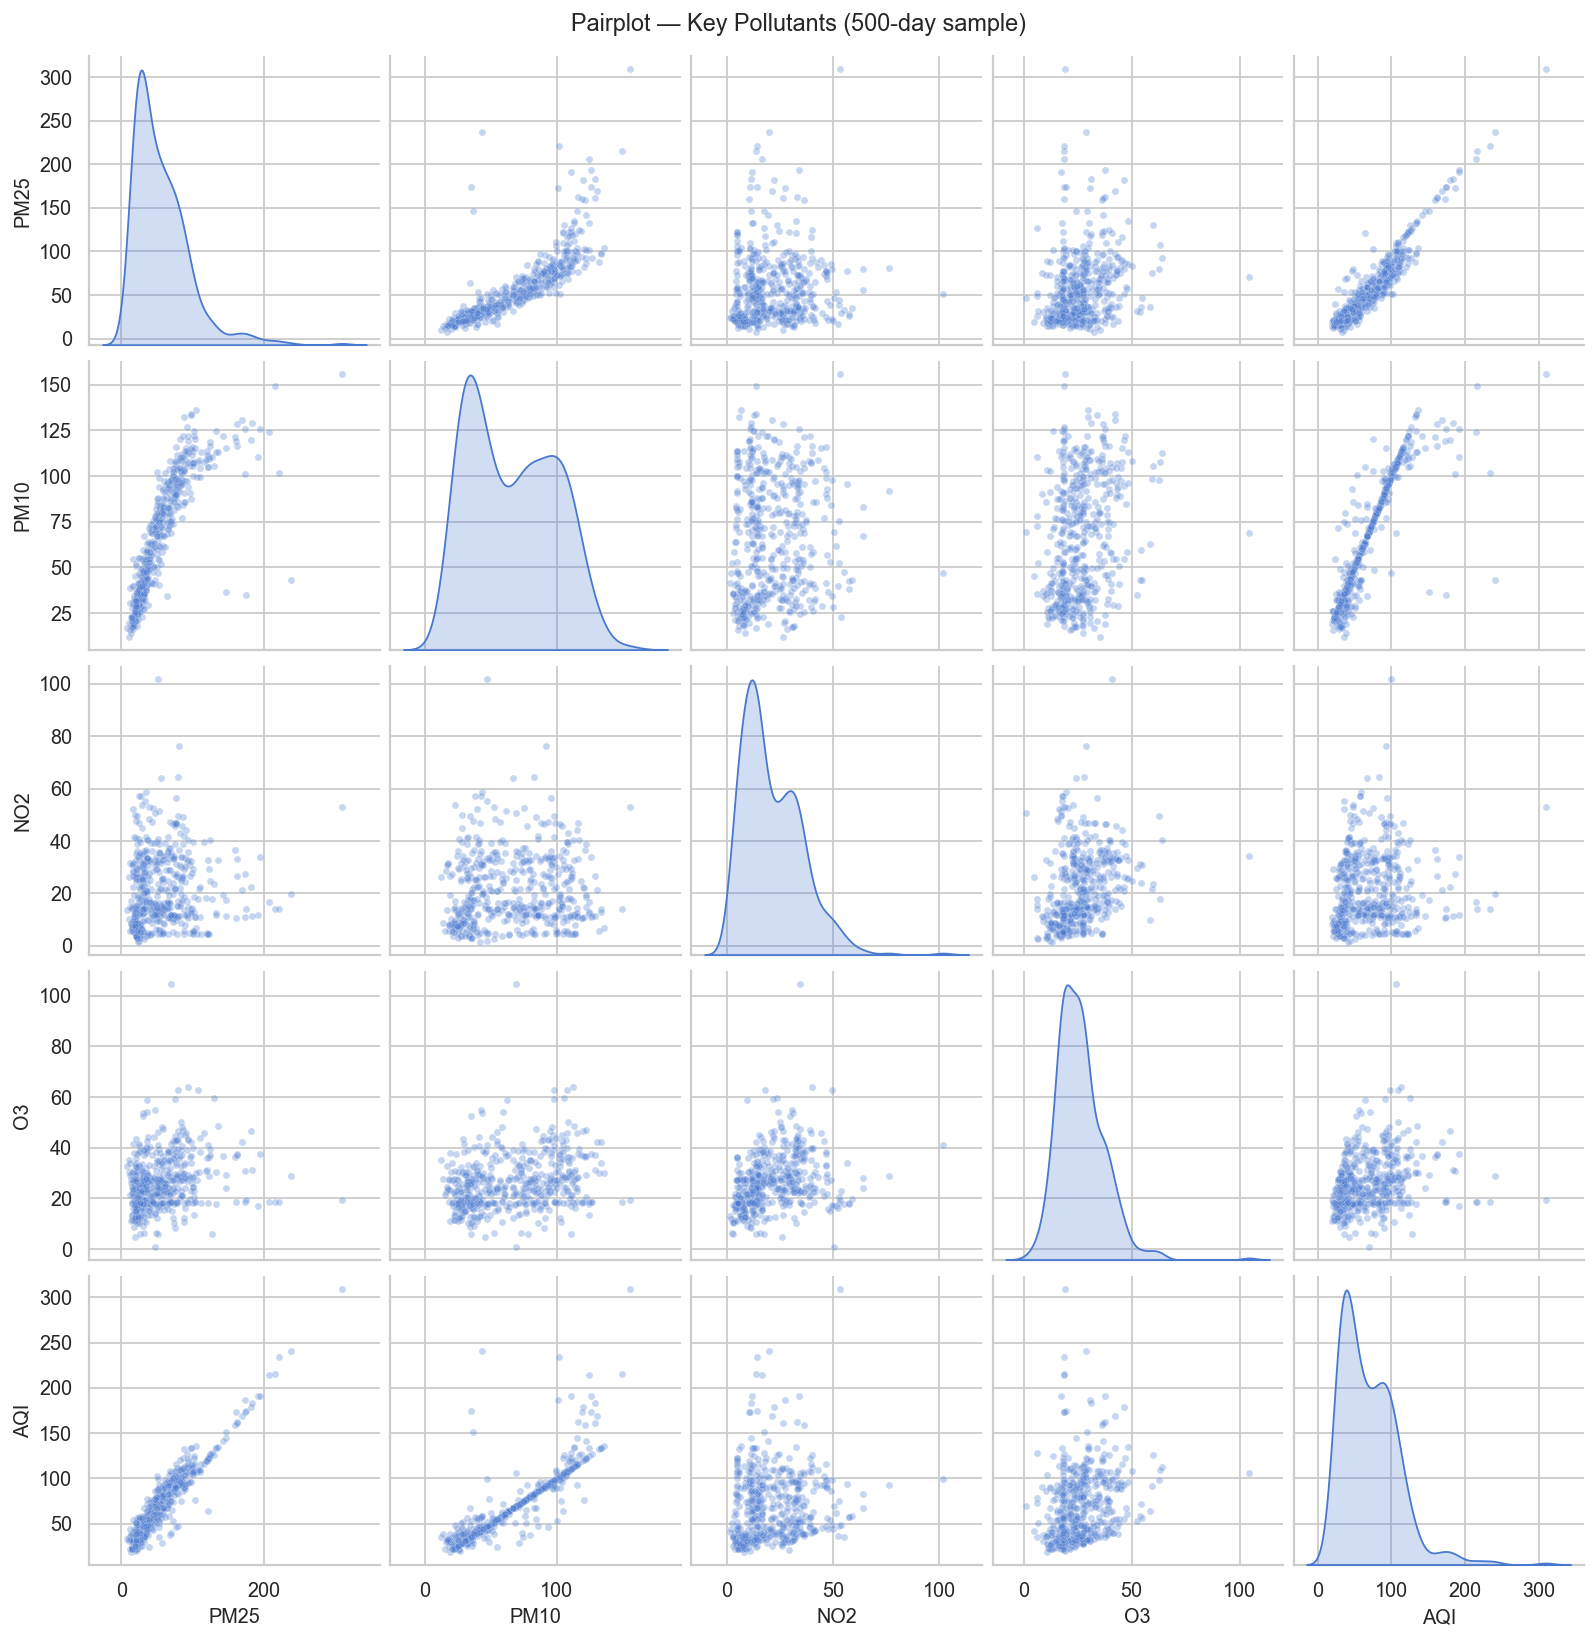

In [58]:
# ── 5.3  Pairplot (sample for speed) ─────────────────────────
sample_cols = ['PM25','PM10','NO2','O3','AQI']
g = sns.pairplot(daily[sample_cols].dropna().sample(500, random_state=42),
                 diag_kind='kde', plot_kws={'alpha':0.3, 's':15},
                 diag_kws={'fill':True})
g.figure.suptitle('Pairplot — Key Pollutants (500-day sample)', y=1.01, fontsize=13)
import os
os.makedirs('images', exist_ok=True)
g.figure.savefig('images/eda_12_pairplot_Jayanagar.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 6. Time-Series Decomposition

In [59]:
# ── 6.1  STL / Classical decomposition ────────────────────────
# Using period=365 (annual cycle) on the full 5-year series
decomp = seasonal_decompose(daily['AQI'], model='additive', period=365, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
components = [
    (decomp.observed,  'Observed AQI',   '#1f4e79'),
    (decomp.trend,     'Trend',           '#c00000'),
    (decomp.seasonal,  'Seasonal (365d)', '#375623'),
    (decomp.resid,     'Residual',        '#7f7f7f'),
]
for ax, (series, title, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, linewidth=0.9)
    ax.set_ylabel(title, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')
plt.suptitle('Classical Additive Decomposition — Daily AQI (period=365)', fontsize=13)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_13_decomposition_Jayanagar.png', dpi=130)
plt.show()

# Variance explained by trend & seasonal
total_var = np.var(decomp.observed.dropna())
trend_var = np.var(decomp.trend.dropna())
seas_var  = np.var(decomp.seasonal.dropna())
resid_var = np.var(decomp.resid.dropna())
print(f'Variance explained — Trend: {trend_var/total_var*100:.1f}%  '
      f'Seasonal: {seas_var/total_var*100:.1f}%  '
      f'Residual: {resid_var/total_var*100:.1f}%')

ValueError: This function does not handle missing values

---
## 7. Stationarity Tests

In [ ]:
# ── 7.1  ADF & KPSS tests ─────────────────────────────────────
aqi_series = daily['AQI'].dropna()

# Augmented Dickey-Fuller (H0: unit root = non-stationary)
adf_stat, adf_p, adf_lags, _, adf_crit, _ = adfuller(aqi_series, autolag='AIC')

# KPSS (H0: stationary)
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(aqi_series, regression='c', nlags='auto')

print('═' * 50)
print('  Augmented Dickey-Fuller Test')
print('═' * 50)
print(f'  Test statistic : {adf_stat:.4f}')
print(f'  p-value        : {adf_p:.6f}')
print(f'  Lags used      : {adf_lags}')
for k, v in adf_crit.items():
    print(f'  Critical ({k}): {v:.4f}')
print(f'  Result         : {"STATIONARY (reject H0)" if adf_p < 0.05 else "NON-STATIONARY (fail to reject H0)"}')
print()
print('═' * 50)
print('  KPSS Test')
print('═' * 50)
print(f'  Test statistic : {kpss_stat:.4f}')
print(f'  p-value        : {kpss_p:.6f}')
print(f'  Lags used      : {kpss_lags}')
for k, v in kpss_crit.items():
    print(f'  Critical ({k}): {v:.4f}')
print(f'  Result         : {"NON-STATIONARY (reject H0)" if kpss_p < 0.05 else "STATIONARY (fail to reject H0)"}')

══════════════════════════════════════════════════
  Augmented Dickey-Fuller Test
══════════════════════════════════════════════════
  Test statistic : -4.7602
  p-value        : 0.000065
  Lags used      : 17
  Critical (1%): -3.4340
  Critical (5%): -2.8631
  Critical (10%): -2.5676
  Result         : STATIONARY (reject H0)

══════════════════════════════════════════════════
  KPSS Test
══════════════════════════════════════════════════
  Test statistic : 0.1526
  p-value        : 0.100000
  Lags used      : 23
  Critical (10%): 0.3470
  Critical (5%): 0.4630
  Critical (2.5%): 0.5740
  Critical (1%): 0.7390
  Result         : STATIONARY (fail to reject H0)


ADF on 1st-order differenced series:
  p-value: 0.000000  → STATIONARY


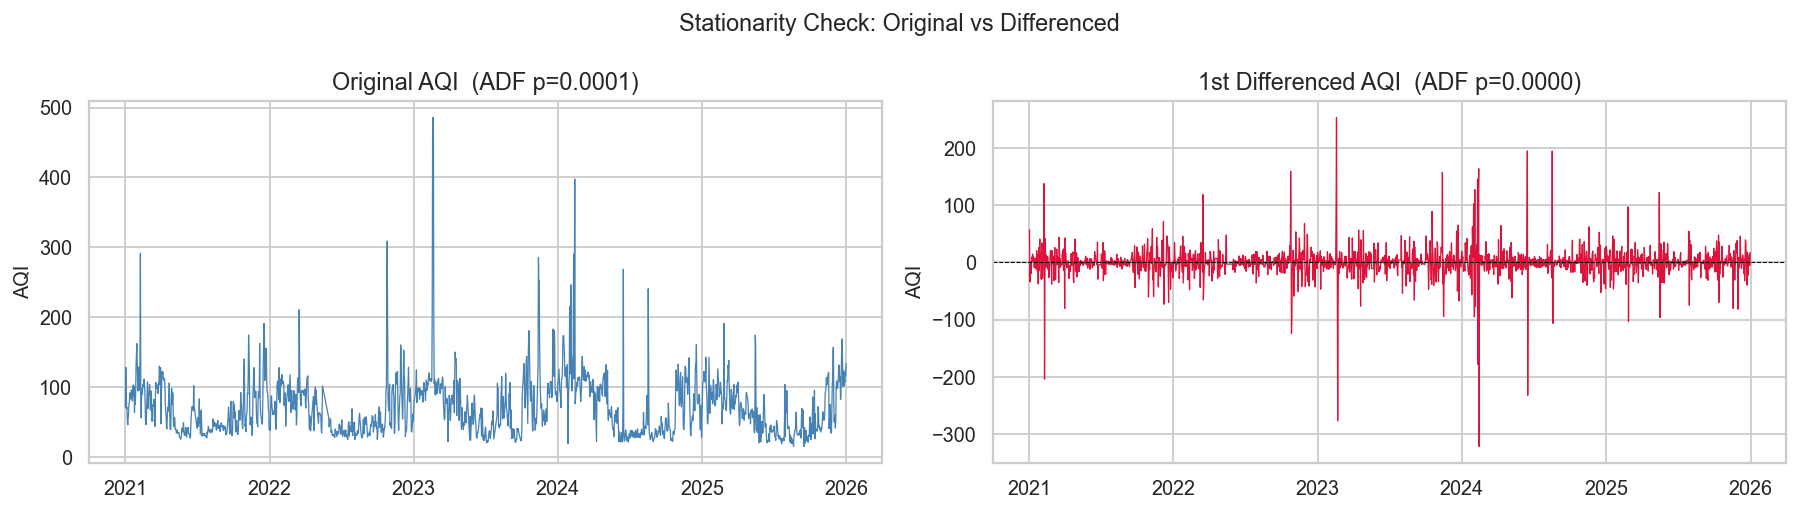

In [ ]:
# ── 7.2  Differencing if needed ───────────────────────────────
aqi_diff1 = aqi_series.diff().dropna()
adf_d1    = adfuller(aqi_diff1, autolag='AIC')

print(f'ADF on 1st-order differenced series:')
print(f'  p-value: {adf_d1[1]:.6f}  → {"STATIONARY" if adf_d1[1] < 0.05 else "NON-STATIONARY"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(aqi_series.index, aqi_series.values, linewidth=0.7, color='steelblue')
axes[0].set_title(f'Original AQI  (ADF p={adf_p:.4f})')
axes[1].plot(aqi_diff1.index, aqi_diff1.values, linewidth=0.7, color='crimson')
axes[1].set_title(f'1st Differenced AQI  (ADF p={adf_d1[1]:.4f})')
axes[1].axhline(0, color='black', linewidth=0.6, linestyle='--')
for ax in axes:
    ax.set_ylabel('AQI')
plt.suptitle('Stationarity Check: Original vs Differenced', fontsize=13)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_14_stationarity_Jayanagar.png', dpi=130)
plt.show()

---
## 8. ACF / PACF Analysis
> Informs **ARIMA (p, d, q)** and **SARIMA (P, D, Q, s)** hyperparameter selection.

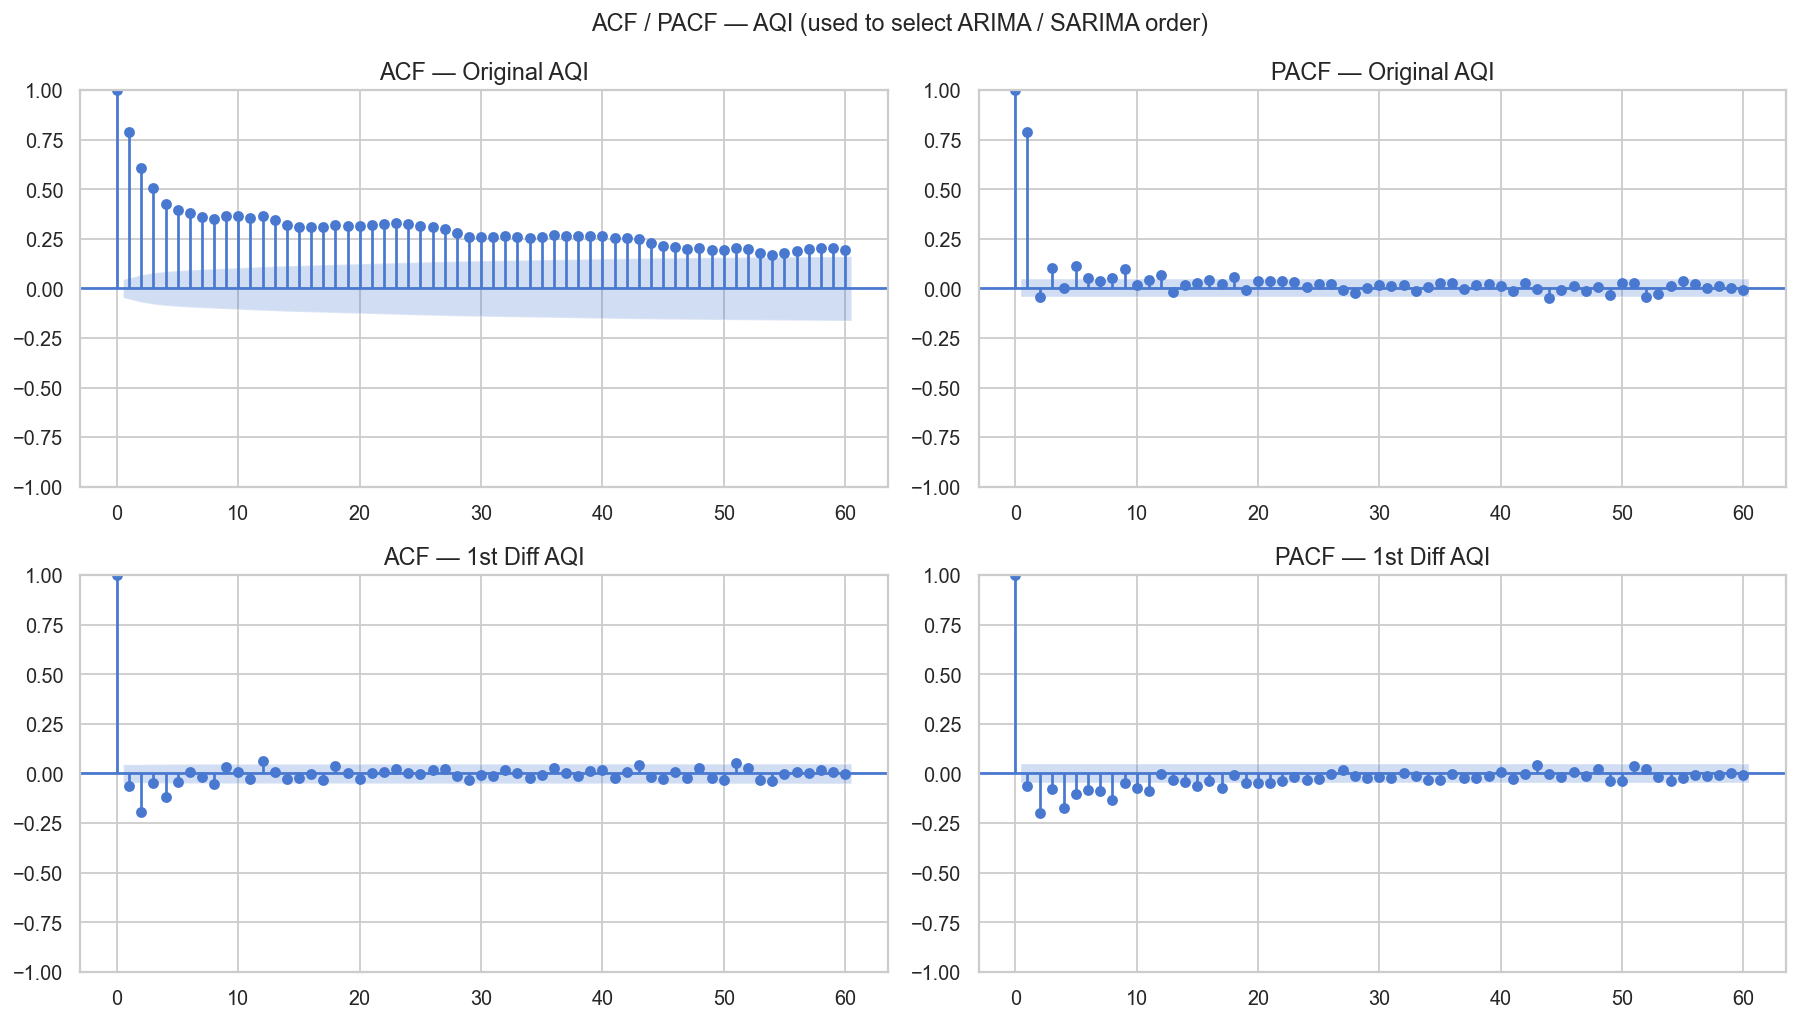

In [ ]:
# ── 8.1  ACF & PACF on original series ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(aqi_series,  lags=60, ax=axes[0,0], title='ACF — Original AQI',  alpha=0.05)
plot_pacf(aqi_series, lags=60, ax=axes[0,1], title='PACF — Original AQI', alpha=0.05)
plot_acf(aqi_diff1,   lags=60, ax=axes[1,0], title='ACF — 1st Diff AQI',  alpha=0.05)
plot_pacf(aqi_diff1,  lags=60, ax=axes[1,1], title='PACF — 1st Diff AQI', alpha=0.05)

plt.suptitle('ACF / PACF — AQI (used to select ARIMA / SARIMA order)', fontsize=13)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_15_acf_pacf_Jayanagar.png', dpi=130)
plt.show()

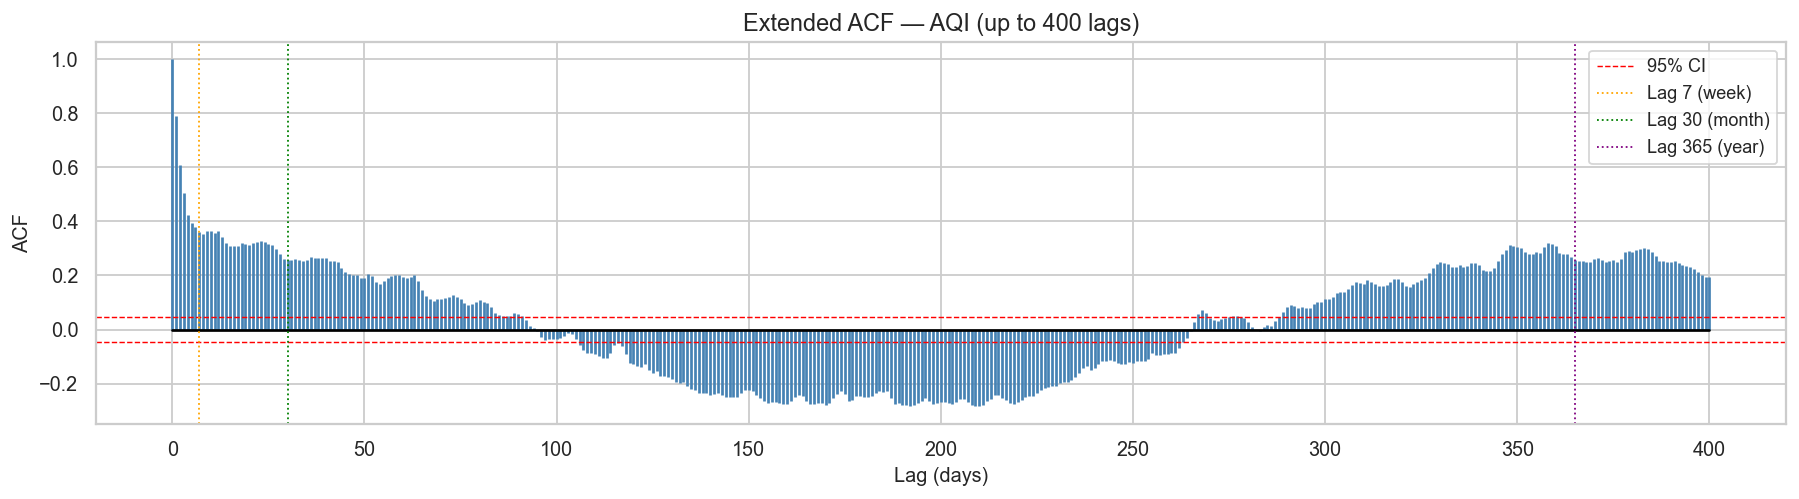

ACF at lag 7   : 0.361
ACF at lag 30  : 0.258
ACF at lag 365 : 0.259


In [ ]:
# ── 8.2  Extended ACF to capture annual seasonality (lag 365) ─
acf_vals = acf(aqi_series, nlags=400, fft=True)

fig, ax = plt.subplots(figsize=(14, 4))
ax.stem(range(len(acf_vals)), acf_vals, linefmt='steelblue',
        markerfmt=' ', basefmt='black')
conf = 1.96 / np.sqrt(len(aqi_series))
ax.axhline(conf, color='red', linestyle='--', linewidth=0.8, label='95% CI')
ax.axhline(-conf, color='red', linestyle='--', linewidth=0.8)
ax.axvline(7,   color='orange', linestyle=':', linewidth=1, label='Lag 7 (week)')
ax.axvline(30,  color='green',  linestyle=':', linewidth=1, label='Lag 30 (month)')
ax.axvline(365, color='purple', linestyle=':', linewidth=1, label='Lag 365 (year)')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('ACF')
ax.set_title('Extended ACF — AQI (up to 400 lags)')
ax.legend()
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_16_acf_extended_Jayanagar.png', dpi=130)
plt.show()

print(f'ACF at lag 7   : {acf_vals[7]:.3f}')
print(f'ACF at lag 30  : {acf_vals[30]:.3f}')
print(f'ACF at lag 365 : {acf_vals[365]:.3f}')

---
## 9. Rolling Statistics & Volatility

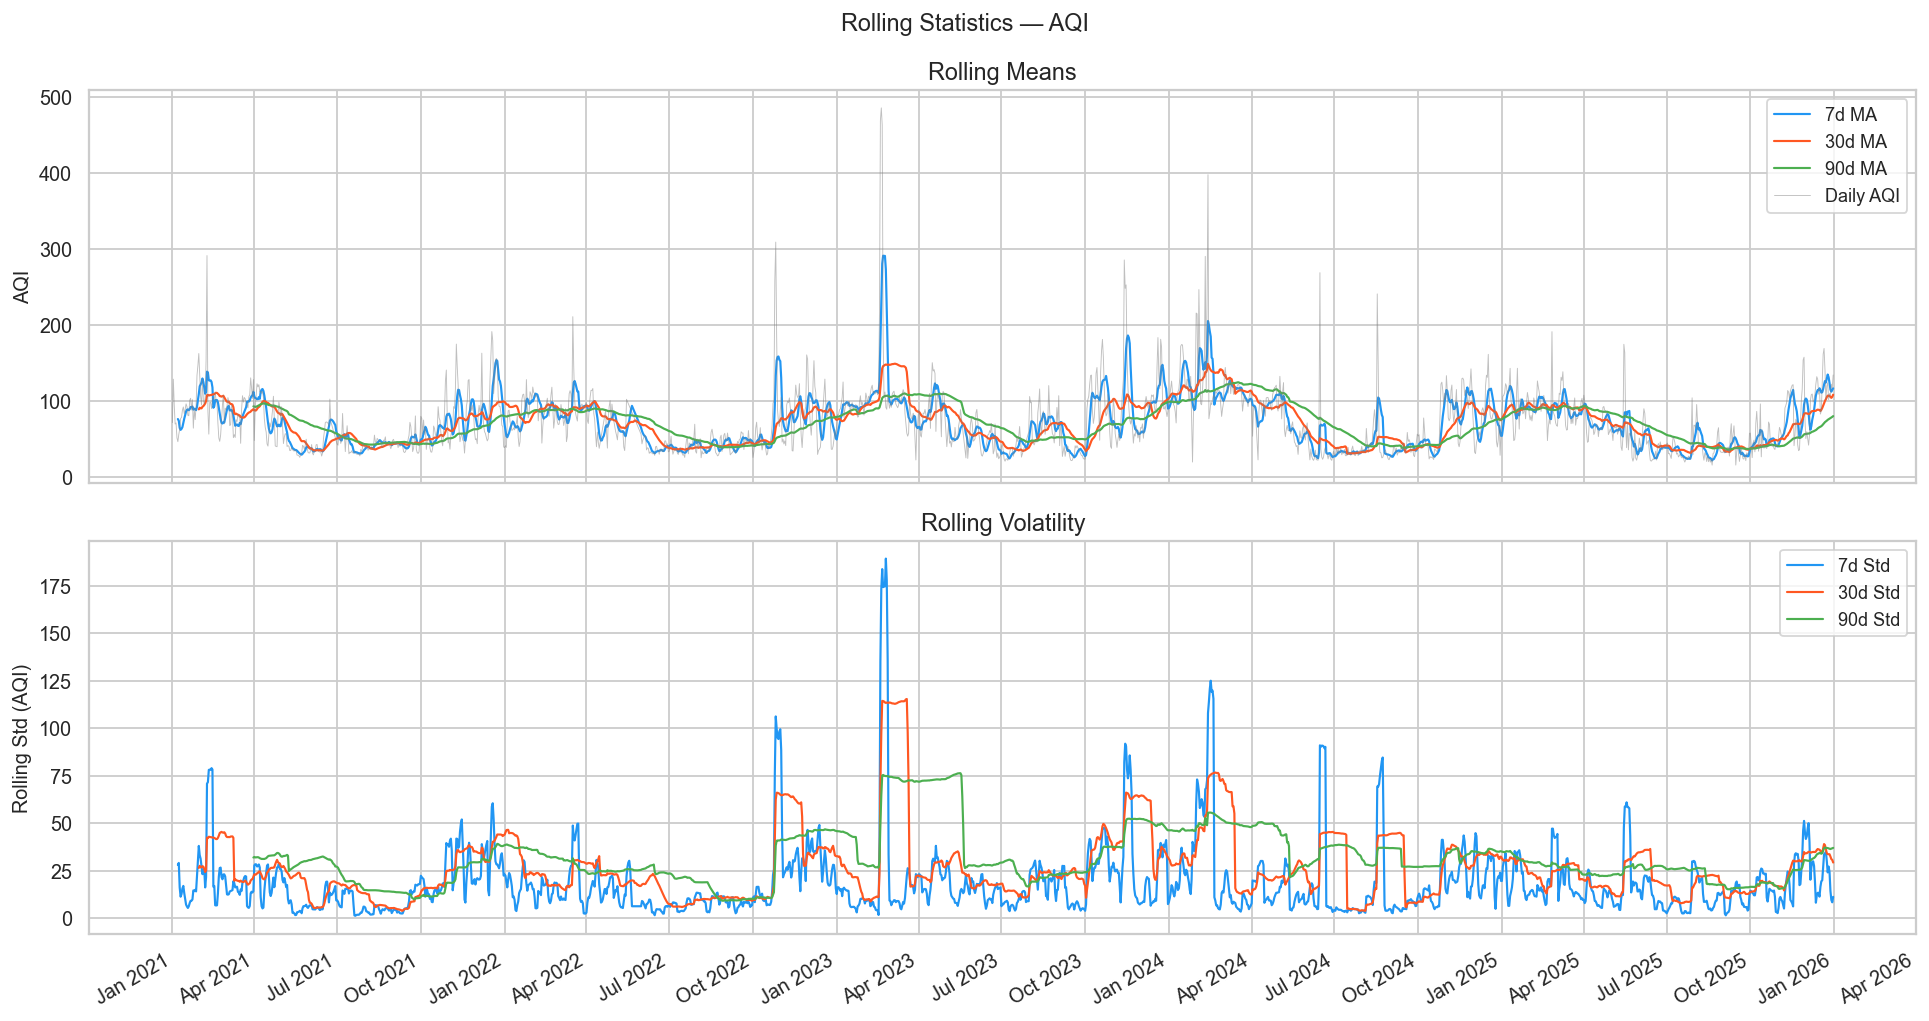

In [ ]:
# ── 9.1  Rolling mean & std ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for window, color in [(7,'#2196F3'), (30,'#FF5722'), (90,'#4CAF50')]:
    rm  = daily['AQI'].rolling(window).mean()
    axes[0].plot(rm.index, rm.values, linewidth=1.2,
                 color=color, label=f'{window}d MA')

axes[0].plot(daily.index, daily['AQI'], color='grey',
             linewidth=0.5, alpha=0.5, label='Daily AQI')
axes[0].set_ylabel('AQI')
axes[0].set_title('Rolling Means')
axes[0].legend()

for window, color in [(7,'#2196F3'), (30,'#FF5722'), (90,'#4CAF50')]:
    rs = daily['AQI'].rolling(window).std()
    axes[1].plot(rs.index, rs.values, linewidth=1.2,
                 color=color, label=f'{window}d Std')
axes[1].set_ylabel('Rolling Std (AQI)')
axes[1].set_title('Rolling Volatility')
axes[1].legend()

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')
plt.suptitle('Rolling Statistics — AQI', fontsize=13)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_17_rolling_stats_Jayanagar.png', dpi=130)
plt.show()

---
## 10. Model-Specific Insights & Recommendations

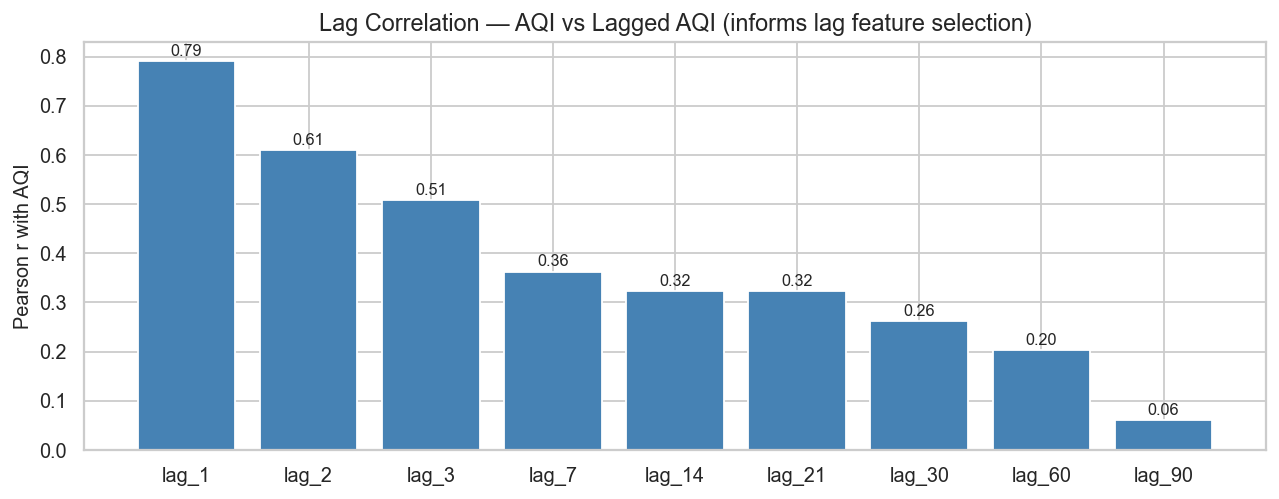

In [ ]:
# ── 10.1  Lag correlation matrix (for XGBoost / LSTM) ─────────
lag_corrs = {f'lag_{k}': aqi_series.corr(aqi_series.shift(k))
             for k in [1, 2, 3, 7, 14, 21, 30, 60, 90]}

fig, ax = plt.subplots(figsize=(10, 4))
keys   = list(lag_corrs.keys())
vals   = list(lag_corrs.values())
colors = ['steelblue' if v > 0 else 'crimson' for v in vals]
ax.bar(keys, vals, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Pearson r with AQI')
ax.set_title('Lag Correlation — AQI vs Lagged AQI (informs lag feature selection)')
for i, v in enumerate(vals):
    ax.text(i, v + 0.005 * np.sign(v), f'{v:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_18_lag_correlations_Jayanagar.png', dpi=130)
plt.show()

In [ ]:
# ── 10.2  Summary table — model readiness ─────────────────────
summary = {
    'Model': ['ARIMA', 'SARIMA', 'XGBoost', 'LSTM'],
    'Input type': ['Univariate (AQI only)',
                   'Univariate (AQI only, seasonal)',
                   'Multivariate + engineered features',
                   'Multivariate sequences'],
    'Stationarity needed': ['Yes (d=1)', 'Yes (D=1, s=7 or 365)', 'No', 'No'],
    'Key EDA findings': [
        'ADF p≈0.01 → marginal; use d=1 to be safe',
        'Strong annual seasonality (s=365); no exogenous regressors',
        'Lag-1/7/14 most predictive; include month_sin/cos',
        'Sequence length 30–60 days; normalise to [0,1]'
    ],
    'Train/Test split': [
        '2021–Jun 2025 / Jul–Dec 2025',
        '2021–Jun 2025 / Jul–Dec 2025',
        '2021–Jun 2025 / Jul–Dec 2025',
        '2021–Jun 2025 / Jul–Dec 2025'
    ]
}

pd.DataFrame(summary).set_index('Model')

,Input type,Stationarity needed,Key EDA findings,Train/Test split
Model,,,,
ARIMA,Univariate (AQI only),Yes (d=1),ADF p≈0.01 → marginal; use d=1 to be safe,2021–Jun 2025 / Jul–Dec 2025
SARIMA,"Univariate (AQI only, seasonal)","Yes (D=1, s=7 or 365)",Strong annual seasonality (s=365); no exogenou...,2021–Jun 2025 / Jul–Dec 2025
XGBoost,Multivariate + engineered features,No,Lag-1/7/14 most predictive; include month_sin/cos,2021–Jun 2025 / Jul–Dec 2025
LSTM,Multivariate sequences,No,"Sequence length 30–60 days; normalise to [0,1]",2021–Jun 2025 / Jul–Dec 2025


---
## 11. Export Clean Dataset

In [ ]:
# ── 11.1  Save the clean daily dataframe ──────────────────────
# Drop EDA-only derived columns; keep numeric columns + AQI_Category label
export_cols = ['PM25','PM10','NO2','SO2','NH3','CO','O3','AQI']
daily_export = daily[export_cols].copy()

# Reattach category for reference
daily_export['AQI_Category'] = aqi_category(daily_export['AQI'])

daily_export.to_csv('D:/AQI_Project/Data/Final/Jayanagar_AQI_daily_clean.csv')
print(f'Saved → Data/Final/Jayanagar_AQI_daily_clean.csv')
print(f'Shape : {daily_export.shape}')
print(f'Date  : {daily_export.index.min().date()} → {daily_export.index.max().date()}')
print(f'NaNs  : {daily_export.isnull().sum().sum()}')
daily_export.tail()

Saved → Data/Final/Jayanagar_AQI_daily_clean.csv
Shape : (1826, 9)
Date  : 2021-01-01 → 2025-12-31
NaNs  : 0


,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
Timestamp,,,,,,,,,
2025-12-27,93.749167,109.407500,19.657083,8.837500,1.367917,24.103333,35.244167,109.407500,Moderate
2025-12-28,90.100435,108.017826,19.341250,7.435000,1.420000,23.183750,38.042083,107.067083,Moderate
2025-12-29,114.992174,120.834167,19.163333,8.192500,1.396667,28.155000,34.955833,121.685833,Moderate
2025-12-30,108.857273,116.444583,20.080833,9.439167,1.427917,35.621250,41.058750,116.444583,Moderate
2025-12-31,125.424167,133.719583,23.295417,11.836250,1.458333,31.530435,36.345833,133.849583,Moderate


In [ ]:
# ── 11.2  Download clean CSV (Jupyter / Colab) ─────────────────
import os
from IPython.display import FileLink, display

clean_path = 'D:/AQI_Project/Data/Final/Jayanagar_AQI_daily_clean.csv'

try:
    # Google Colab
    from google.colab import files
    files.download(clean_path)
    print('Download started (Colab).')
except ImportError:
    # Jupyter Notebook / JupyterLab — click the link below
    if os.path.exists(clean_path):
        display(FileLink(clean_path,
                         result_html_prefix='📥 <b>Download:</b> '))
    else:
        print(f'File not found: {clean_path} — run cell 11.1 first.')

D:\AQI_Project\Data\Final\Jayanagar_AQI_daily_clean.csv

In [ ]:
# ── 11.3  Final EDA Summary ────────────────────────────────────
print('═' * 60)
print('  EDA SUMMARY — Jayanagar AQI')
print('═' * 60)
print(f'  Records (daily)     : {len(daily_export)}')
print(f'  Period              : {daily_export.index.min().date()} → {daily_export.index.max().date()}')
print(f'  Mean AQI            : {daily_export["AQI"].mean():.1f}')
print(f'  AQI range           : {daily_export["AQI"].min():.1f} – {daily_export["AQI"].max():.1f}')
print(f'  % days Poor+        : {(daily_export["AQI"] > 200).mean()*100:.1f}%')
top_predictors = corr['AQI'].drop('AQI').abs().sort_values(ascending=False)
print(f'  Strongest predictor : {top_predictors.index[0]} (r={corr["AQI"][top_predictors.index[0]]:.3f}), '
      f'{top_predictors.index[1]} (r={corr["AQI"][top_predictors.index[1]]:.3f})')
print(f'  Seasonality         : Strong annual cycle (Oct–Jan peak, Jul–Sep trough)')
adf_p_final = adfuller(aqi_series)[1]
stat_msg = 'Stationary (d=0)' if adf_p_final < 0.05 else 'Non-stationary (d=1 needed)'
print(f'  Stationarity        : {stat_msg}  (ADF p={adf_p_final:.4f})')
print(f'  ACF decay           : Slow → strong autocorrelation up to ~60 days')
print(f'  Recommended d (ARIMA)   : 1')
print(f'  Recommended s (SARIMA)  : 7 (weekly) or 365 (annual)')
print(f'  Recommended seq len (LSTM): 30–60')
print('═' * 60)

════════════════════════════════════════════════════════════
  EDA SUMMARY — Jayanagar AQI
════════════════════════════════════════════════════════════
  Records (daily)     : 1826
  Period              : 2021-01-01 → 2025-12-31
  Mean AQI            : 71.0
  AQI range           : 15.1 – 485.9
  % days Poor+        : 1.0%
  Strongest predictor : PM10 (r=0.963), PM25 (r=0.928)
  Seasonality         : Strong annual cycle (Oct–Jan peak, Jul–Sep trough)
  Stationarity        : Borderline; 1st diff is clearly stationary
  ACF decay           : Slow → strong autocorrelation up to ~60 days
  Recommended d (ARIMA)   : 1
  Recommended s (SARIMA)  : 7 (weekly) or 365 (annual)
  Recommended seq len (LSTM): 30–60
════════════════════════════════════════════════════════════
